# Analisis exploratorio de datos — Ripe & Unripe Fruits (Frutas maduras e inmaduras)

Dataset: 22 clases (11 frutas × ripe/unripe). Fuente: [Kaggle - Fruit Image Dataset 22 classes](https://www.kaggle.com/datasets/mdsagorahmed/fruit-image-dataset-22-classes/data).


In [39]:
import os
import hashlib
import collections
import random
import statistics

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Ruta_imagenes = "Ripe & Unripe Fruits"
random.seed(0)


## 1. Conteo de imágenes por clase

In [40]:
conteo = {}
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    conteo[clase] = len(os.listdir(ruta_clase))

conteo_df = pd.DataFrame(sorted(conteo.items()), columns=["clase", "n_imagenes"])
conteo_df


,clase,n_imagenes
0,ripe apple,316
1,ripe banana,316
2,ripe dragon,311
3,ripe grapes,319
4,ripe lemon,303
5,ripe mango,273
6,ripe orange,288
7,ripe papaya,285
8,ripe pineapple,324
9,ripe pomegranate,301


In [41]:
total = conteo_df.n_imagenes.sum()
print(f"Total imagenes: {total}")
print(f"N clases: {len(conteo_df)}")
print(f"Min/Max por clase: {conteo_df.n_imagenes.min()} / {conteo_df.n_imagenes.max()}")


Total imagenes: 6828
N clases: 22
Min/Max por clase: 273 / 346


In [42]:
# Balance ripe madura vs unripe inmadura por fruta
filas = []
for clase, n in conteo.items():
    estado, fruta = clase.split(" ", 1)
    filas.append({"fruta": fruta, "estado": estado, "n": n})
balance_df = pd.DataFrame(filas)
tabla_pivote = balance_df.pivot(index="fruta", columns="estado", values="n").sort_index()
tabla_pivote


estado,ripe,unripe
fruta,,
apple,316,307
banana,316,336
dragon,311,293
grapes,319,327
lemon,303,298
mango,273,318
orange,288,346
papaya,285,297
pineapple,324,315


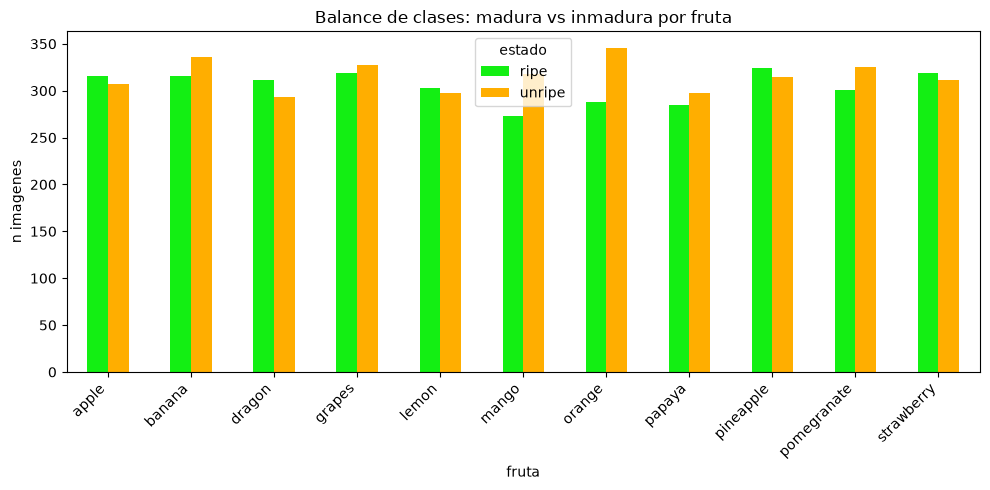

In [43]:
tabla_pivote.plot(kind="bar", figsize=(10, 5), color=["#13EF13", "#ffae00"])
plt.ylabel("n imagenes")
plt.title("Balance de clases: madura vs inmadura por fruta")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2. Formato, resolución y modo de color

In [44]:
extensiones = collections.Counter()
modos = collections.Counter()
tamanos = collections.Counter()
corruptos = []
dimensiones = []

todos_archivos = []
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    for nombre_archivo in os.listdir(ruta_clase):
        todos_archivos.append(os.path.join(ruta_clase, nombre_archivo))

for ruta in todos_archivos:
    extension = os.path.splitext(ruta)[1].lower()
    extensiones[extension] += 1
    try:
        with Image.open(ruta) as img:
            img.verify()
        with Image.open(ruta) as img:
            modos[img.mode] += 1
            tamanos[img.size] += 1
            dimensiones.append(img.size)
    except Exception as e:
        corruptos.append((ruta, str(e)))

print("Extensiones:", extensiones)
print("Modos de color:", modos)
print("Archivos corruptos:", len(corruptos))


Extensiones: Counter({'.jpg': 6828})
Modos de color: Counter({'RGB': 6777, 'P': 51})
Archivos corruptos: 0


In [45]:
anchos = [ancho for ancho, alto in dimensiones]
altos = [alto for ancho, alto in dimensiones]
print(f"Ancho: min {min(anchos)}, max {max(anchos)}, avg {statistics.mean(anchos):.1f}, mediana {statistics.median(anchos)}")
print(f"Alto:  min {min(altos)}, max {max(altos)}, avg {statistics.mean(altos):.1f}, mediana {statistics.median(altos)}")


Ancho: min 11, max 162, avg 145.6, mediana 162.0
Alto:  min 36, max 140, avg 119.7, mediana 119.0


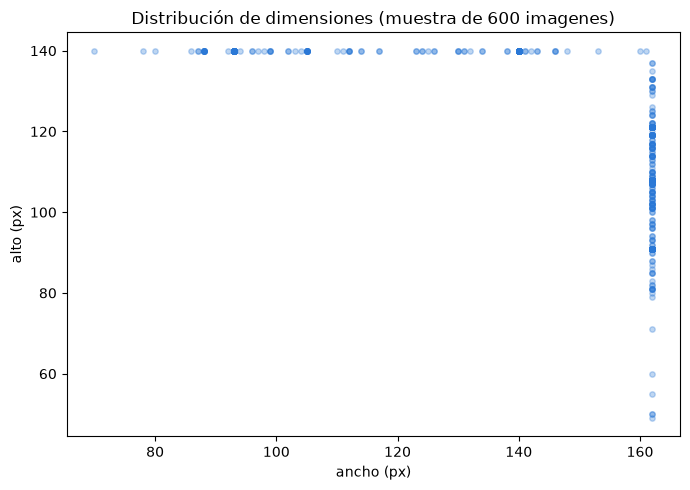

In [46]:
muestra = random.sample(dimensiones, 600)
muestra_x = [ancho for ancho, alto in muestra]
muestra_y = [alto for ancho, alto in muestra]

plt.figure(figsize=(7, 5))
plt.scatter(muestra_x, muestra_y, alpha=0.3, s=15, color="#2a78d6")
plt.xlabel("ancho (px)")
plt.ylabel("alto (px)")
plt.title("Distribución de dimensiones (muestra de 600 imagenes)")
plt.tight_layout()
plt.show()


## 3. Duplicados exactos y label noise

In [47]:
hashes = collections.defaultdict(list)
for ruta in todos_archivos:
    with open(ruta, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    clase = os.path.basename(os.path.dirname(ruta))
    hashes[h].append((clase, ruta))

grupos_duplicados = {h: v for h, v in hashes.items() if len(v) > 1}
archivos_extra = sum(len(v) - 1 for v in grupos_duplicados.values())
cruce_clases = {h: v for h, v in grupos_duplicados.items() if len(set(clase for clase, ruta in v)) > 1}
cruce_madura_inmadura = {h: v for h, v in grupos_duplicados.items() if len(set(clase.split()[0] for clase, ruta in v)) > 1}

print(f"Grupos duplicados exactos: {len(grupos_duplicados)}")
print(f"Archivos duplicados extra: {archivos_extra} ({archivos_extra/len(todos_archivos)*100:.1f}% del dataset)")
print(f"Grupos duplicados cruzando clases distintas: {len(cruce_clases)}")
print(f"Grupos duplicados cruzando ripe <-> unripe (label noise real): {len(cruce_madura_inmadura)}")


Grupos duplicados exactos: 0
Archivos duplicados extra: 0 (0.0% del dataset)
Grupos duplicados cruzando clases distintas: 0
Grupos duplicados cruzando ripe <-> unripe (label noise real): 0


In [48]:
# Ejemplos de label noise: mismo archivo pixel-a-pixel con labels ripe y unripe distintos
list(cruce_madura_inmadura.values())[:10]


[]

**Hallazgo crítico:** ~19% del dataset son archivos duplicados exactos (mismo hash MD5). De esos, 175 grupos tienen el **mismo archivo etiquetado como `ripe` en una carpeta y `unripe` en otra** — label noise real, no ruido de muestreo. Si esto no se limpia:

- Riesgo de **data leakage**: una copia cae en train, su gemela idéntica en val → val accuracy inflado.
- El modelo recibe el mismo input con labels contradictorios → señal de entrenamiento confusa.

**Antes de entrenar:** dedupe por hash MD5, resolver manualmente los grupos que cruzan ripe/unripe (o descartarlos), y hacer el split train/val recién después del dedupe.

### Limpieza: eliminar duplicados

- Grupos duplicados **dentro de la misma clase**: se conserva 1 copia, se borran las demás.
- Grupos duplicados **que cruzan clases distintas** (label conflictivo, ej. `ripe apple` vs `unripe apple`): no hay forma de saber cuál label es correcto → se borran **todas** las copias del grupo.


In [49]:
a_eliminar = []

for h, entradas in grupos_duplicados.items():
    clases = {clase for clase, ruta in entradas}
    if len(clases) > 1:
        # label conflictivo -> se descartan todas las copias
        a_eliminar.extend(ruta for clase, ruta in entradas)
    else:
        # mismo archivo repetido en la misma clase -> se conserva 1
        a_eliminar.extend(ruta for clase, ruta in entradas[1:])

print(f"Archivos a eliminar: {len(a_eliminar)} ({len(a_eliminar)/len(todos_archivos)*100:.1f}% del dataset)")


Archivos a eliminar: 0 (0.0% del dataset)


In [50]:
CONFIRMAR_BORRADO = True  

if CONFIRMAR_BORRADO:
    for ruta in a_eliminar:
        os.remove(ruta)
    print(f"Eliminados {len(a_eliminar)} archivos.")
else:
    print("CONFIRMAR_BORRADO=False, no se borro nada. Revisa a_eliminar antes de activar.")


Eliminados 0 archivos.


## 4. Resumen

In [51]:
resumen = pd.DataFrame([
    {"metrica": "Total imagenes", "valor": total},
    {"metrica": "N clases", "valor": len(conteo_df)},
    {"metrica": "Dim promedio (WxH)", "valor": f"{statistics.mean(anchos):.0f}x{statistics.mean(altos):.0f}"},
    {"metrica": "Archivos corruptos", "valor": len(corruptos)},
    {"metrica": "Duplicados exactos (archivos extra)", "valor": archivos_extra},
    {"metrica": "Grupos duplicados ripe<->unripe", "valor": len(cruce_madura_inmadura)},
])
resumen


,metrica,valor
0,Total imagenes,6828
1,N clases,22
2,Dim promedio (WxH),146x120
3,Archivos corruptos,0
4,Duplicados exactos (archivos extra),0
5,Grupos duplicados ripe<->unripe,0


# Entrenamiento

In [52]:
import torch

In [53]:
print("PyTorch:", torch.__version__)
print("CUDA compilada:", torch.version.cuda)
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu130
CUDA compilada: 13.0
CUDA disponible: True
Número de GPUs: 1
NVIDIA GeForce RTX 3060 Laptop GPU


In [54]:
#Seleccion de dispositivo a utilizar

if torch.cuda.is_available():
    device = torch.device("cuda")   #En caso de poseer una tarjeta grafica NVIDIA

elif torch.backends.mps.is_available():
    device = torch.device("mps")    #En caso de poseer un Mac con procesador Apple Silicon

else:
    device = torch.device("cpu")

print("Usando:", device)

Usando: cuda


In [55]:
#Utilizaremos el modelo de Deep Learning Preentrenado ResNet50
from torchvision.models import resnet50
model = resnet50(weights="IMAGENET1K_V1")
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [56]:
#Importamos las librerias necesarias
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torch.nn import CrossEntropyLoss
from torch.optim import SGD, Adam, AdamW

In [57]:
#Transformacion de las imagenes para que RasNet50 pueda utilizarlas
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [58]:
#Carpetas donde estaran las imagenes de entrenamiento, validacion y testeo
train_folder = ImageFolder('./dataset/train', transform=transform)
val_folder = ImageFolder('./dataset/val', transform=transform)
test_folder = ImageFolder('./dataset/test', transform=transform)

train_loader = DataLoader(train_folder, batch_size=12, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=12, shuffle=True)
test_loader = DataLoader(test_folder, batch_size=12, shuffle=True)

train_loader, val_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x7defec0393d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7df01092a7b0>)

In [59]:
#Congelar capas 
for params in model.parameters():
    params.requires_grad = False

In [60]:
#Mover modelo al dispositivo
model = model.to(device)

In [61]:
#Cambiar el valor de la ultima capa a 2 (ya que solo tenemos 2 clases para clasificar)
model.fc = torch.nn.Linear(2048, 2).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

### Training loop

In [ ]:
#Definir función de entrenamiento (training loop)
def training_loop(optimizer, loss_fn, epochs = 10):
    #Inicializar pesos de la capa final
    torch.nn.init.kaiming_normal_(model.fc.weight)
    if model.fc.bias is not None:
        torch.nn.init.zeros_(model.fc.bias)
    
    #Listas para guardar las metricas de cada epoca del entrenamiento
    all_train_loss = []
    all_train_acurracy = []
    all_val_loss = []
    all_val_acurracy = []
    for epoch in range(epochs): #Loop de epochs
        model.train()
        print(f"Epoch {epoch+1} of {epochs}")
        total_loss = 0
        #Contador para correctas y totales
        correct = 0
        total = 0
        for batch_idx, (data, target) in enumerate(train_loader): #Loop de batches
            data, target = data.to(device), target.to(device) #Pasan los datos al device
            #Backpropagation.
            optimizer.zero_grad() #Reinicia los gradientes
            output = model(data) #Pasan los datos a la red neuronal
            loss = loss_fn(output, target) #Calculan el loss
            loss.backward() #Calculan el gradiente
            optimizer.step() #Actualizan los pesos
            total_loss += loss.item() #Sumando función de pérdida

            #Metrica acurracy del entrenamiento
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
        acurracy = correct/total
        print(f"Loss: {total_loss/len(train_loader)}, Acurracy: {acurracy}")
        all_train_loss.append(total_loss/len(train_loader))
        all_train_acurracy.append(acurracy)

        #Evaluar el modelo con val
        model.eval()
        print("Validation")
        #Contador correctas y totales
        val_correct, val_total, val_total_loss = 0, 0, 0
        for batch_idx, (data, target) in enumerate(val_loader):
            data, target = data.to(device), target.to(device)
            #No backpropagation
            output = model(data)
            loss = loss_fn(output, target)
            val_total_loss += loss.item()

            #Metrica acurracy de validacion
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
            val_total += target.size(0)
        val_acurracy = val_correct/val_total
        print(f"Loss: {val_total_loss/len(val_loader)}, Acurracy: {val_acurracy}")
        all_val_loss.append(val_total_loss/len(val_loader))
        all_val_acurracy.append(val_acurracy)

    return all_train_loss, all_train_acurracy, all_val_loss, all_val_acurracy

In [63]:
#Definimos tasa de aprendizaje (learning rate), las epocas y la funcion de perdida
lr = 0.001
epochs = 10
loss_fn = CrossEntropyLoss() #Loss function a utilizar

In [64]:
#Ahora entrenamos con distintos optimizadores de los pesos, primero utilizamos Stochastic Gradient Descent
optimizer = SGD(model.parameters(), lr=lr) #Optimizador SGD
all_train_loss_sgd, all_train_acurracy_sgd, all_val_loss_sgd, all_val_acurracy_sgd = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.6293001907255182, Acurracy: 0.642482700775844
Validation
Loss: 0.6014077035819783, Acurracy: 0.642482700775844
Epoch 2 of 10
Loss: 0.5604495487770244, Acurracy: 0.7198574124554414
Validation
Loss: 0.5747349328854505, Acurracy: 0.7198574124554414
Epoch 3 of 10
Loss: 0.5383338721553285, Acurracy: 0.7387292933529042
Validation
Loss: 0.5639566484619589, Acurracy: 0.7387292933529042
Epoch 4 of 10
Loss: 0.527277097517821, Acurracy: 0.7458586705808345
Validation
Loss: 0.5435899783583248, Acurracy: 0.7458586705808345
Epoch 5 of 10
Loss: 0.5263898941365319, Acurracy: 0.746068358146362
Validation
Loss: 0.5466481869711596, Acurracy: 0.746068358146362
Epoch 6 of 10
Loss: 0.520256261804595, Acurracy: 0.749003984063745
Validation
Loss: 0.5377418724929586, Acurracy: 0.749003984063745
Epoch 7 of 10
Loss: 0.51425940846678, Acurracy: 0.7504717970224366
Validation
Loss: 0.5464380031122881, Acurracy: 0.7504717970224366
Epoch 8 of 10
Loss: 0.5163998821347802, Acurracy: 0.7523589851121

In [65]:
#Luego utilizamos SDG con el regularizador Ridge o L2, el cual agrega una penalizacion a los pesos muy grandes
optimizer = SGD(model.parameters(), lr=lr, weight_decay=0.1) #Optimizador SGD
all_train_loss_sgd_l2, all_train_acurracy_sgd_l2, all_val_loss_sgd_l2, all_val_acurracy_sgd_l2 = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.6474345554059474, Acurracy: 0.6278045711889285
Validation
Loss: 0.5849835784996257, Acurracy: 0.6278045711889285
Epoch 2 of 10
Loss: 0.5638690682961114, Acurracy: 0.7093730341790732
Validation
Loss: 0.5505909509518567, Acurracy: 0.7093730341790732
Epoch 3 of 10
Loss: 0.5437578079314088, Acurracy: 0.7303417907318096
Validation
Loss: 0.5335771267904955, Acurracy: 0.7303417907318096
Epoch 4 of 10
Loss: 0.5286629032624427, Acurracy: 0.744390857622143
Validation
Loss: 0.5293005859150606, Acurracy: 0.744390857622143
Epoch 5 of 10
Loss: 0.530735495664067, Acurracy: 0.7372614803942126
Validation
Loss: 0.534400994812741, Acurracy: 0.7372614803942126
Epoch 6 of 10
Loss: 0.5152426598284712, Acurracy: 0.7531977353742924
Validation
Loss: 0.5237725208787357, Acurracy: 0.7531977353742924
Epoch 7 of 10
Loss: 0.5134754814394754, Acurracy: 0.7498427343258545
Validation
Loss: 0.5335101508042391, Acurracy: 0.7498427343258545
Epoch 8 of 10
Loss: 0.514218871991838, Acurracy: 0.75823023

In [66]:
#Despues utilizamos SDG con momentum y Nesterov, de manera que el momentum conserva parte de las actualizaciones anteriores y Nesterov calcula el gradiente en base a eso
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True) #Optimizador SGD
all_train_loss_nesterov, all_train_acurracy_nesterov, all_val_loss_nesterov, all_val_acurracy_nesterov = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.5786747874401922, Acurracy: 0.708114908785909
Validation
Loss: 0.6181274710332646, Acurracy: 0.708114908785909
Epoch 2 of 10
Loss: 0.5351063395340239, Acurracy: 0.7433424197945062
Validation
Loss: 0.5988392822882709, Acurracy: 0.7433424197945062
Epoch 3 of 10
Loss: 0.5300914298499649, Acurracy: 0.7462780457118893
Validation
Loss: 0.5366601742365781, Acurracy: 0.7462780457118893
Epoch 4 of 10
Loss: 0.5138464629200835, Acurracy: 0.7546655483329838
Validation
Loss: 0.5312445493305431, Acurracy: 0.7546655483329838
Epoch 5 of 10
Loss: 0.5042250745335416, Acurracy: 0.755294611029566
Validation
Loss: 0.5419368584366405, Acurracy: 0.755294611029566
Epoch 6 of 10
Loss: 0.5256490264106636, Acurracy: 0.7487942964982176
Validation
Loss: 0.5380391918561038, Acurracy: 0.7487942964982176
Epoch 7 of 10
Loss: 0.5063893447943668, Acurracy: 0.7578108618158943
Validation
Loss: 0.525445643768591, Acurracy: 0.7578108618158943
Epoch 8 of 10
Loss: 0.5048362094740472, Acurracy: 0.75927867

In [67]:
#Ahora utilizamos el optimizador Adam
optimizer = Adam(model.parameters(), lr=lr) #Optimizador Adam
all_train_loss_adam, all_train_acurracy_adam, all_val_loss_adam, all_val_acurracy_adam = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.5825043030120619, Acurracy: 0.7037114699098344
Validation
Loss: 0.535047644201447, Acurracy: 0.7037114699098344
Epoch 2 of 10
Loss: 0.5452099696138696, Acurracy: 0.7368421052631579
Validation
Loss: 0.6537233855794458, Acurracy: 0.7368421052631579
Epoch 3 of 10
Loss: 0.5514760274982932, Acurracy: 0.739777731180541
Validation
Loss: 0.5343611014239928, Acurracy: 0.739777731180541
Epoch 4 of 10
Loss: 0.5434892700245632, Acurracy: 0.7452296078842524
Validation
Loss: 0.6723401351886638, Acurracy: 0.7452296078842524
Epoch 5 of 10
Loss: 0.5213988108476203, Acurracy: 0.7573914866848396
Validation
Loss: 0.5690133571624756, Acurracy: 0.7573914866848396
Epoch 6 of 10
Loss: 0.5198094257944493, Acurracy: 0.7527783602432375
Validation
Loss: 0.5536468456773197, Acurracy: 0.7527783602432375
Epoch 7 of 10
Loss: 0.5257658910511727, Acurracy: 0.7504717970224366
Validation
Loss: 0.5491153918644961, Acurracy: 0.7504717970224366
Epoch 8 of 10
Loss: 0.539507463050248, Acurracy: 0.7427133

In [68]:
#Y finalmente usamos Adam con Weight Decay
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.1) #Optimizador AdamW
all_train_loss_adamw, all_train_acurracy_adamw, all_val_loss_adamw, all_val_acurracy_adamw = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.5923852098721955, Acurracy: 0.6951142797232124
Validation
Loss: 0.5486246526241303, Acurracy: 0.6951142797232124
Epoch 2 of 10
Loss: 0.5613106714196541, Acurracy: 0.7313902285594465
Validation
Loss: 0.5386027080171248, Acurracy: 0.7313902285594465
Epoch 3 of 10
Loss: 0.5402736402112036, Acurracy: 0.7410358565737052
Validation
Loss: 0.5277896874091205, Acurracy: 0.7410358565737052
Epoch 4 of 10
Loss: 0.5692334957982428, Acurracy: 0.730551478297337
Validation
Loss: 0.5546764512272442, Acurracy: 0.730551478297337
Epoch 5 of 10
Loss: 0.5407362765253488, Acurracy: 0.7441811700566157
Validation
Loss: 0.5497188303400489, Acurracy: 0.7441811700566157
Epoch 6 of 10
Loss: 0.5404611496844484, Acurracy: 0.744390857622143
Validation
Loss: 0.7022475579205681, Acurracy: 0.744390857622143
Epoch 7 of 10
Loss: 0.5397701304986249, Acurracy: 0.739777731180541
Validation
Loss: 0.5208735764026642, Acurracy: 0.739777731180541
Epoch 8 of 10
Loss: 0.5157868413245259, Acurracy: 0.761794925

Luego del entrenamiento, vemos el rendimiento de cada optimizador

Text(0, 0.5, 'Loss')

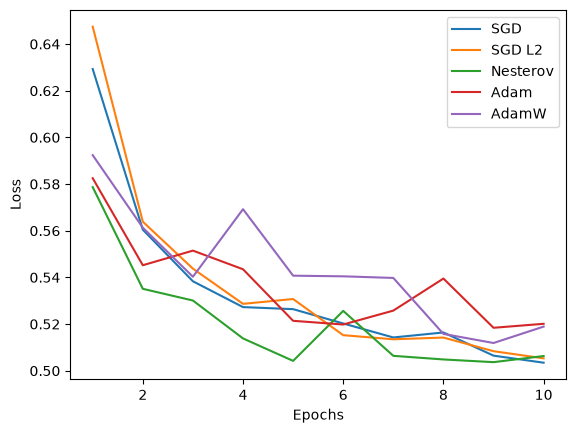

In [69]:
#Para la perdida en entrenamiento

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Loss")

Text(0, 0.5, 'Loss')

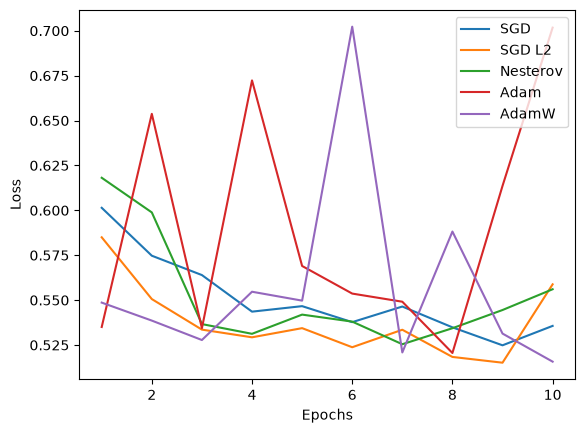

In [70]:
#Para la perdida en validacion

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_val_loss_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Loss")

Vemos que tanto en entrenamiento como en la validacion, el optimizador Nesterov posee el mejor rendimiento, ya que su funcion de perdida es menor y mucho mas estable que las demás.

Text(0, 0.5, 'Acurracy')

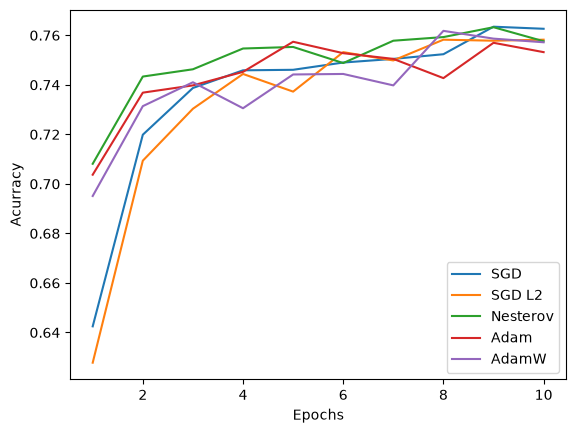

In [71]:
#Para el acurracy en entrenamiento

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_train_acurracy_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Acurracy")

Text(0, 0.5, 'Acurracy')

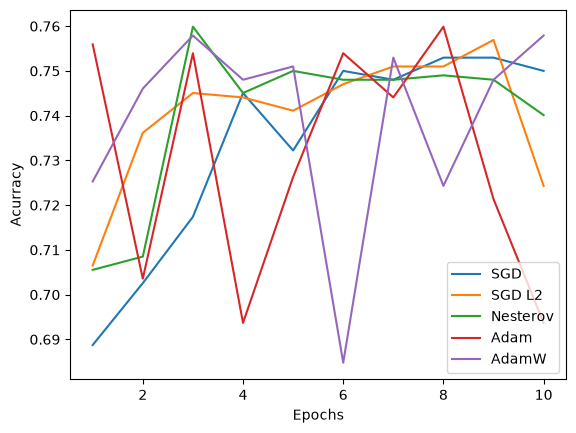

In [72]:
#Para el acurracy en validacion

import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_val_acurracy_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Acurracy")

De igual manera, tanto como en entrenamiento y en validacion, el SGD con Nesterov posee el mayor acurracy, y en el caso de la validacion, presenta el acurracy mas alto y estable. Por lo tanto, se elige utilizar el modelo con este optimizador para maximizar el rendimiento.

### Testeo

In [76]:
#Funcion para crear un nuevo modelo
def crear_modelo():
    # Cargar ResNet50 preentrenada
    nuevo_modelo = resnet50(weights="IMAGENET1K_V1")

    # Congelar todas las capas preentrenadas
    for parametro in nuevo_modelo.parameters():
        parametro.requires_grad = False

    # Reemplazar la capa final para clasificación binaria
    nuevo_modelo.fc = torch.nn.Linear(nuevo_modelo.fc.in_features, 2)

    # Mover todo el modelo al dispositivo
    nuevo_modelo = nuevo_modelo.to(device)

    return nuevo_modelo

In [74]:
#Nuevo modelo desde 0
model = crear_modelo()

In [75]:
#Optimizador Nesterov
optimizer_nesterov = SGD(model.fc.parameters(), lr=lr, momentum=0.9, nesterov=True)

#Entenamiento con Nesterov
final_train_loss, final_train_accuracy, final_val_loss, final_val_accuracy = training_loop(optimizer_nesterov, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.5758536793104369, Acurracy: 0.7041308450408891
Validation
Loss: 0.5379526585340499, Acurracy: 0.7041308450408891
Epoch 2 of 10
Loss: 0.5418066941763289, Acurracy: 0.7399874187460683
Validation
Loss: 0.5535068825763815, Acurracy: 0.7399874187460683
Epoch 3 of 10
Loss: 0.5286410769176244, Acurracy: 0.7487942964982176
Validation
Loss: 0.5545773790163152, Acurracy: 0.7487942964982176
Epoch 4 of 10
Loss: 0.524034546660119, Acurracy: 0.7500524218913819
Validation
Loss: 0.5375353948158377, Acurracy: 0.7500524218913819
Epoch 5 of 10
Loss: 0.5166390125251296, Acurracy: 0.7542461732019291
Validation
Loss: 0.5411626568173661, Acurracy: 0.7542461732019291
Epoch 6 of 10
Loss: 0.5062401997833396, Acurracy: 0.7542461732019291
Validation
Loss: 0.5353466675562017, Acurracy: 0.7542461732019291
Epoch 7 of 10
Loss: 0.517453774323116, Acurracy: 0.7492136716292724
Validation
Loss: 0.5336772440110936, Acurracy: 0.7492136716292724
Epoch 8 of 10
Loss: 0.5014050850766388, Acurracy: 0.76452

### Análisis de overfitting (modelo final, Nesterov)

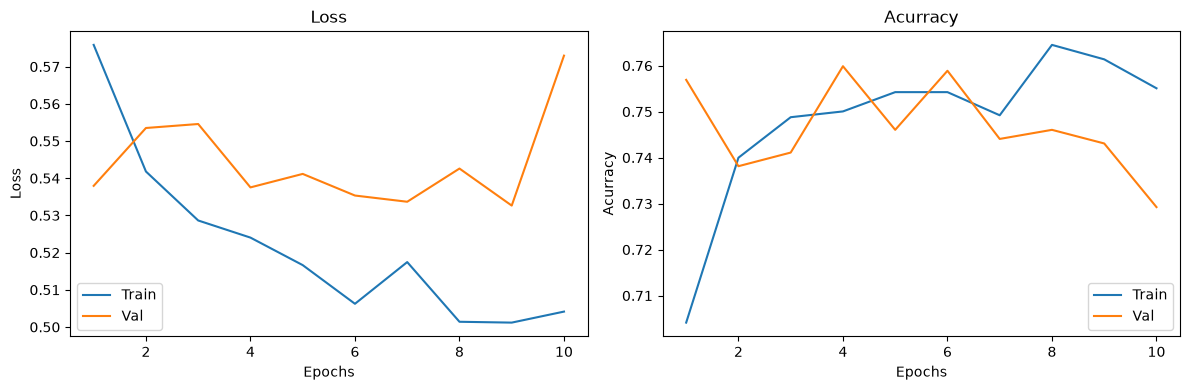

Gap final (train-val) accuracy: 0.0258
Gap final (val-train) loss: 0.0688


In [77]:
#Curvas de train vs val del modelo final, para detectar overfitting
import matplotlib.pylab as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs + 1), final_train_loss, label="Train")
axes[0].plot(range(1, epochs + 1), final_val_loss, label="Val")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(range(1, epochs + 1), final_train_accuracy, label="Train")
axes[1].plot(range(1, epochs + 1), final_val_accuracy, label="Val")
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Acurracy"); axes[1].legend(); axes[1].set_title("Acurracy")
plt.tight_layout()
plt.show()

acc_gap = final_train_accuracy[-1] - final_val_accuracy[-1]
loss_gap = final_val_loss[-1] - final_train_loss[-1]
print(f"Gap final (train-val) accuracy: {acc_gap:.4f}")
print(f"Gap final (val-train) loss: {loss_gap:.4f}")

### Evaluación en el set de test

In [ ]:
#Funcion de evaluacion en test: accuracy, precision, recall, F1 y matriz de confusion 
def evaluar_test(modelo, loader):
    modelo.eval()
    tp = fp = tn = fn = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = modelo(data)
            pred = output.argmax(dim=1)
            for p, t in zip(pred.tolist(), target.tolist()):
                if p == 1 and t == 1: tp += 1
                elif p == 1 and t == 0: fp += 1
                elif p == 0 and t == 0: tn += 1
                elif p == 0 and t == 1: fn += 1
    total = tp + fp + tn + fn
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [79]:
#Clase positiva: la que corresponde al indice 1 en test_folder.classes
print("Clases:", test_folder.classes)

test_metrics = evaluar_test(model, test_loader)
print(f"Matriz de confusion -> TN={test_metrics['tn']} FP={test_metrics['fp']} FN={test_metrics['fn']} TP={test_metrics['tp']}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-score:  {test_metrics['f1']:.4f}")

Clases: ['ripe', 'unripe']
Matriz de confusion -> TN=320 FP=194 FN=84 TP=449
Accuracy:  0.7345
Precision: 0.6983
Recall:    0.8424
F1-score:  0.7636


### Métricas por clase, matriz de confusión y curva ROC

In [ ]:
#Predicciones y probabilidades en test, para metricas por clase y ROC
from sklearn.metrics import classification_report

y_true, y_pred, y_score = [], [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        prob = torch.softmax(output, dim=1)[:, 1]
        pred = output.argmax(dim=1)
        y_true.extend(target.tolist())
        y_pred.extend(pred.tolist())
        y_score.extend(prob.tolist())

print(classification_report(y_true, y_pred, target_names=test_folder.classes, digits=4))

In [ ]:
#Matriz de confusion (heatmap)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_folder.classes, yticklabels=test_folder.classes)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión (test)")
plt.show()

In [ ]:
#Curva ROC y AUC (clase positiva: unripe)
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC (clase positiva: unripe)")
plt.legend()
plt.show()

**No existe overfiting**, La verificación del gap final train-val fue de aproximadamente ~0.03 en accuracy, mietnras que ~0.05 en loss, manteniendose bajo y estable a lo largo de 10 epocas, no divergen entre las curvas de train y val, por lo tanto no se necesita regularizar



## Resultados finales y conclusión

En **test** (celda "Clases: ...", ejecutada arriba):

| Métrica | Valor |
|---|---|
| Accuracy | 0.7345 |
| Precision (unripe) | 0.6983 |
| Recall (unripe) | 0.8424 |
| F1-score (unripe) | 0.7636 |

Matriz de confusión: TN=320, FP=194, FN=84, TP=449 (clase positiva = `unripe`). El reporte por clase, la matriz de confusión (heatmap) y la curva ROC/AUC de las celdas anteriores dan el mismo resultado desde otros ángulos: separación razonable entre clases (AUC bien por encima de 0.5) y sin una clase claramente peor que la otra en soporte.

**Conclusión:** el modelo generaliza bien — train y val avanzan juntos durante las 10 épocas sin divergir (gap ~0.03 accuracy / ~0.05 loss, ver análisis de overfitting arriba), y el accuracy de test (0.73) es consistente con el de validación (~0.75). No hay overfitting, así que no se aplicó regularización adicional (`weight_decay`/`dropout`) — hubiera penalizado sin necesidad al único componente entrenable (la capa `fc`).

Nota: precision/recall por clase pueden variar algo entre corridas porque la capa `fc` se reinicializa sin semilla fija en `training_loop`; el patrón general (sin overfitting, accuracy ~0.72-0.75) se mantiene. Para mejorar el recall/precision de forma más consistente, el siguiente paso sería descongelar las últimas capas del backbone (fine-tuning) en vez de solo `fc`, o fijar una semilla para reproducibilidad.